# El metano que los polos no supieron contar

Durante décadas, la historia del metano atmosférico se leyó en Groenlandia y la Antártida. El problema es que el metano no se fabrica ahí.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Un equipo perforó hielo a 6.768 metros en los Andes peruanos y sacó unos 2.000 años de aire tropical. Ese registro va por encima del polar en 119 de 123 comparaciones preindustriales: 31 muestras tropicales cruzadas contra cuatro testigos de hielo.

**Paper:** Lamantia et al. (2026). *A global atmospheric methane record from a tropical ice core*. Nature.
**DOI:** [10.1038/s41586-026-10938-1](https://doi.org/10.1038/s41586-026-10938-1)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-19-metano-tropical-huascaran/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/eFBHwEd7lAw)

## Por qué importa dónde perforas

El aire queda atrapado en burbujas dentro del hielo. Perforas, bajas por capas cada vez más viejas y vas leyendo la atmósfera hacia atrás. Es la única forma directa de saber cuánto metano (CH₄) había en el aire antes de que existieran los instrumentos.

Casi todos esos testigos se sacan de los polos, porque ahí el hielo es grueso y estable. Pero el metano de origen natural sale sobre todo de humedales tropicales, y una molécula tarda en mezclarse por toda la atmósfera. Si mides solo en los extremos del planeta, el trópico te llega diluido y con retraso.

El Nevado Huascarán (−9,122° S / −77,605° O, 6.768 m) está a nueve grados del ecuador. Es el primer registro histórico global de CH₄ tomado en latitudes bajas. Vamos a abrir los datos y ver qué cambia.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CORTE_PREINDUSTRIAL = 1750      # año CE que separa preindustrial de industrial
MAUNA_LOA_2024      = 1946.3    # ppb, promedio global NOAA 2024
COLOR_TROPICO       = '#DC2626'   # Huascarán (el registro nuevo)
COLOR_DATOS         = '#2563EB'   # azul CaM
COLOR_MODERNO       = '#059669'   # Mauna Loa (medición instrumental)
COLOR_REFERENCIA    = '#D97706'   # umbrales y líneas de referencia
COLOR_CONTEXTO      = '#BBBBBB'   # registros polares de fondo
FUENTE = ('Fuente: Lamantia et al. (2026), Nature  |  '
          'Datos: Zenodo 10.5281/zenodo.18657346')

def es(x, dec=1):
    """Formato numérico español para el texto de las gráficas: coma decimal."""
    return f'{x:.{dec}f}'.replace('.', ',')

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d, uniform_filter1d

BASE = ('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/'
        'papers/2026-08-19-metano-tropical-huascaran')

# Estilo CaM: local primero, GitHub como respaldo (para Colab)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Descarga automática si falta algún CSV (Colab)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
ARCHIVOS = ['ch4_registros.csv', 'd13c_registros.csv', 'huascaran_20yr_avgs.csv',
            'mitchell_gisp2.csv', 'mitchell_wais.csv', 'rhodes_neem.csv']
for a in ARCHIVOS:
    if not os.path.exists(f'datos/{a}'):
        urllib.request.urlretrieve(f'{BASE}/datos/{a}', f'datos/{a}')

# ── Carga ──────────────────────────────────────────────────────
ch4  = pd.read_csv('datos/ch4_registros.csv')     # year_CE, ch4_ppb, registro
d13c = pd.read_csv('datos/d13c_registros.csv')    # year_CE, d13c_permil, registro

sca    = ch4[ch4.registro == 'Huascaran_SCA'].sort_values('year_CE')
polar  = ['WAIS', 'LawDome', 'GISP2', 'NEEM']
sca_pi = sca[sca.year_CE < CORTE_PREINDUSTRIAL]

print('CH4 — registros cargados:')
for r, n in ch4.groupby('registro').size().sort_values(ascending=False).items():
    sub = ch4[ch4.registro == r]
    print(f'  {r:<15} n={n:>4}   {sub.year_CE.min():>8.0f} a {sub.year_CE.max():>6.0f} CE')
print(f'\nHuascaran SCA: {len(sca)} muestras, span '
      f'{sca.year_CE.max() - sca.year_CE.min():.0f} años')
print(f'Preindustrial (<{CORTE_PREINDUSTRIAL} CE): n={len(sca_pi)}, '
      f'media {sca_pi.ch4_ppb.mean():.1f} ppb, '
      f'mediana {sca_pi.ch4_ppb.median():.1f} ppb, '
      f'IQR {sca_pi.ch4_ppb.quantile(.25):.1f}-{sca_pi.ch4_ppb.quantile(.75):.1f} ppb')
print(f'Ultimo dato del testigo ({sca.year_CE.max():.0f} CE): '
      f'{sca.ch4_ppb.iloc[-1]:.0f} ppb')

CH4 — registros cargados:
  LawDome         n= 329        155 a   1996 CE
  WAIS            n= 228         -1 a   1906 CE
  GISP2           n= 172         -0 a   1824 CE
  NEEM            n= 129        510 a   1960 CE
  Huascaran_SCA   n=  50       -165 a   2012 CE
  MaunaLoa        n=   8       1987 a   2024 CE

Huascaran SCA: 50 muestras, span 2177 años
Preindustrial (<1750 CE): n=32, media 765.4 ppb, mediana 765.5 ppb, IQR 756.8-778.8 ppb
Ultimo dato del testigo (2012 CE): 1838 ppb


Aquí están.

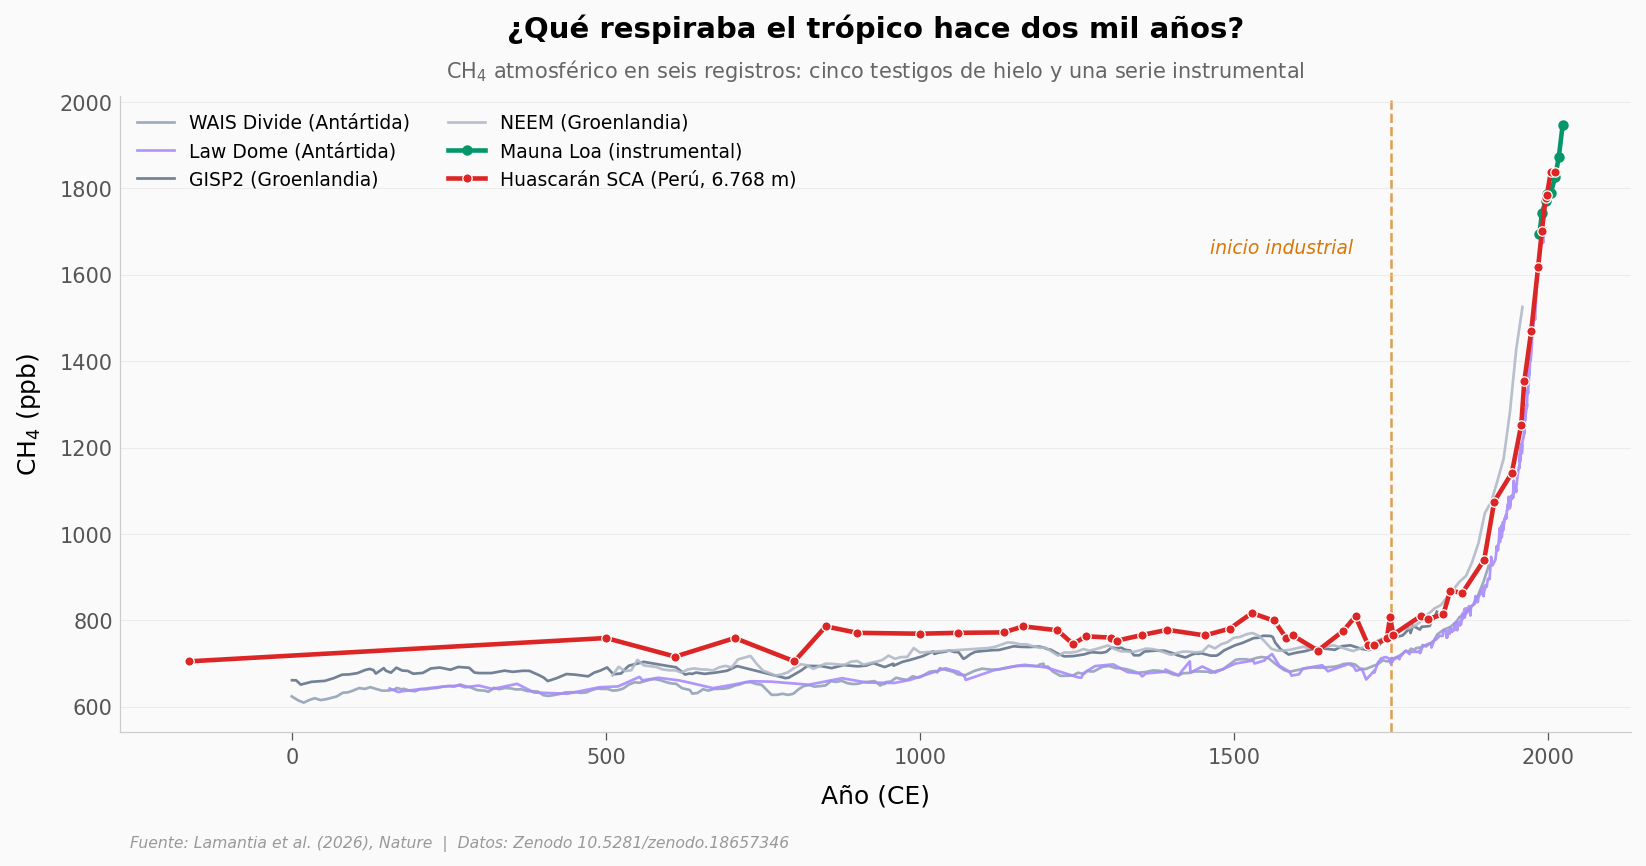

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Registros polares de fondo, en grises fríos
estilo_polar = {'WAIS':    ('#94A3B8', 'WAIS Divide (Antártida)'),
                'LawDome': ('#A78BFA', 'Law Dome (Antártida)'),
                'GISP2':   ('#64748B', 'GISP2 (Groenlandia)'),
                'NEEM':    ('#B0BAC7', 'NEEM (Groenlandia)')}
for reg, (col, etiqueta) in estilo_polar.items():
    s = ch4[ch4.registro == reg].sort_values('year_CE')
    ax.plot(s.year_CE, s.ch4_ppb, color=col, linewidth=1.3, alpha=0.9,
            label=etiqueta, zorder=2)

# Mauna Loa: la medición instrumental moderna
ml = ch4[ch4.registro == 'MaunaLoa'].sort_values('year_CE')
ax.plot(ml.year_CE, ml.ch4_ppb, color=COLOR_MODERNO, linewidth=2.2,
        marker='o', markersize=4, label='Mauna Loa (instrumental)', zorder=4)

# El registro nuevo, encima de todo
ax.plot(sca.year_CE, sca.ch4_ppb, color=COLOR_TROPICO, linewidth=2.2,
        marker='o', markersize=4.5, markeredgecolor='white',
        markeredgewidth=0.6, label='Huascarán SCA (Perú, 6.768 m)', zorder=6)

ax.axvline(CORTE_PREINDUSTRIAL, color=COLOR_REFERENCIA, linewidth=1.2,
           linestyle='--', alpha=0.7, zorder=1)
ax.text(CORTE_PREINDUSTRIAL - 60, 1650, 'inicio industrial', fontsize=9,
        color=COLOR_REFERENCIA, ha='right', style='italic')

ax.set_title('¿Qué respiraba el trópico hace dos mil años?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'CH$_4$ atmosférico en seis registros: cinco testigos de hielo y una serie instrumental',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año (CE)')
ax.set_ylabel('CH$_4$ (ppb)')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9, ncol=2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/series_ch4.png', dpi=200, bbox_inches='tight')
plt.show()

Dos cosas de golpe.

La primera es la subida vertical del final: el testigo peruano marca **1.838 ppb** en 2012, frente a una media preindustrial de **765 ppb** (mediana 765,5; IQR 757–779, n=32). Es **2,4 veces** el nivel de fondo, un **+140%**. Mauna Loa siguió subiendo después: **1.946 ppb** de promedio global en 2024.

La segunda es más sutil y es la que importa aquí. En los dos milenios previos a 1750, la línea roja corre casi siempre por encima: está sobre los cuatro testigos polares en 28 de las 31 muestras comparables, y las tres excepciones (1634, 1724 y 1744) la dejan apenas por debajo de Groenlandia, hasta −6,0 ppb. Las tendencias sí coinciden a grandes rasgos con las polares —que es exactamente lo que el paper afirma—, pero con un desnivel sistemático y muy desigual: +85,4 ppb de media contra los testigos antárticos frente a +38,9 contra los de Groenlandia (Cohen's d = 2,06 entre ambos pares), con un rango total de −6,0 a +136,2 ppb.

Ese desnivel es todo el resultado. Vamos a medirlo.

## ¿Cuánto más alto, exactamente?

Para cada muestra preindustrial del Huascarán interpolamos el valor de cada testigo polar en ese mismo año y restamos. Si el trópico y los polos contaran la misma historia, esas diferencias se repartirían alrededor de cero.

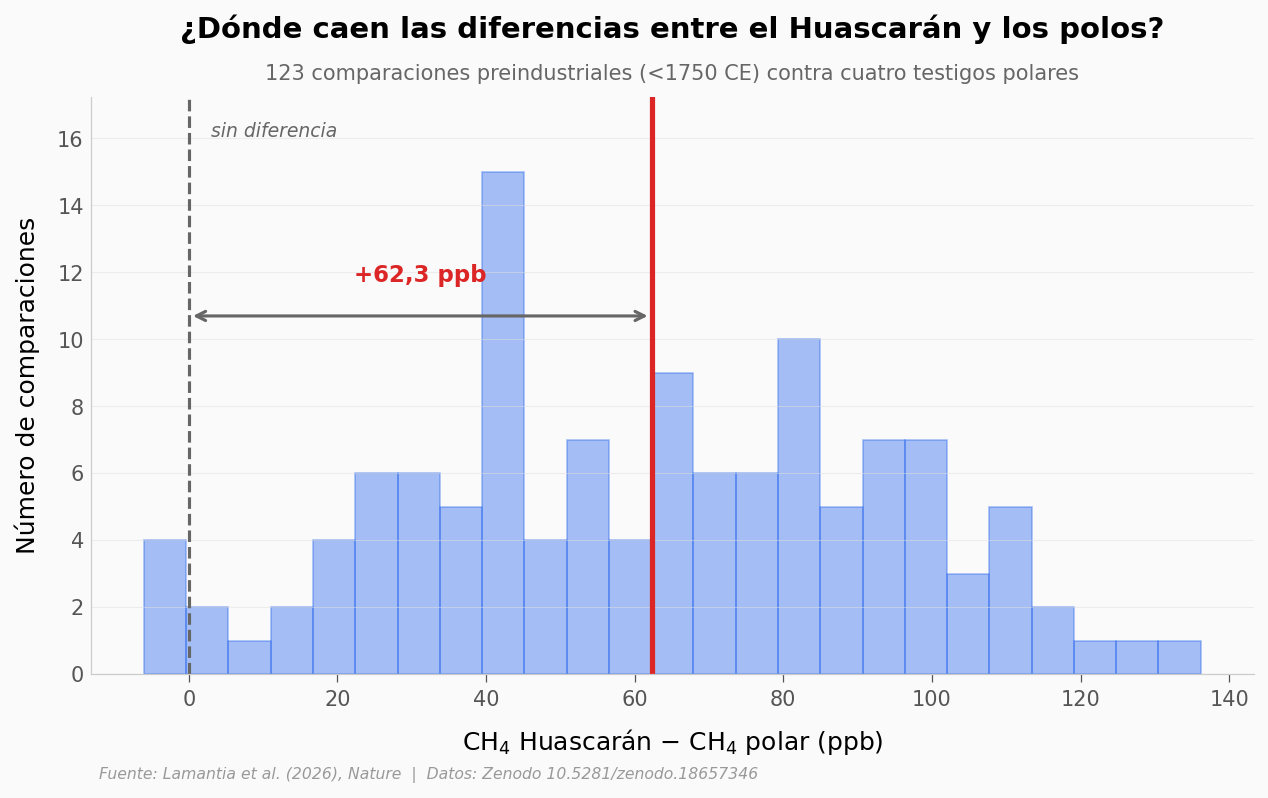

Diferencia media    : +62.3 ppb
Diferencia mediana  : +62.8 ppb
Positivas           : 119 de 123

Por testigo:
  WAIS       +86.2 ppb   (31/31 positivas)
  LawDome    +84.6 ppb   (31/31 positivas)
  GISP2      +41.2 ppb   (30/31 positivas)
  NEEM       +36.5 ppb   (27/30 positivas)

SCA vs Law Dome (preindustrial, n=31):
  Shapiro-Wilk p: SCA=0.562, Law Dome=0.666 -> normales, Pearson válido
  Pearson  r=0.518 (r2=0.268, p=0.0029)
  Spearman rho=0.471 (p=0.0075)


In [3]:
# Diferencia SCA − polar, interpolando cada testigo al año de cada muestra tropical
difs, por_registro = [], {}
for reg in polar:
    p = ch4[ch4.registro == reg].sort_values('year_CE')
    interp = np.interp(sca_pi.year_CE, p.year_CE, p.ch4_ppb,
                       left=np.nan, right=np.nan)
    d = sca_pi.ch4_ppb.values - interp
    d = d[~np.isnan(d)]
    por_registro[reg] = d
    difs.extend(d)
difs = np.array(difs)

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, _ = ax.hist(difs, bins=25, color=COLOR_DATOS, alpha=0.4,
                     edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=0, color='#666666', linewidth=1.5, linestyle='--')
ax.axvline(x=difs.mean(), color=COLOR_TROPICO, linewidth=2.5)
ax.annotate('', xy=(difs.mean(), y_max * 0.62), xytext=(0, y_max * 0.62),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(difs.mean() / 2, y_max * 0.68, f'+{es(difs.mean())} ppb',
        fontsize=11, fontweight='bold', color=COLOR_TROPICO, ha='center')
ax.text(3, y_max * 0.93, 'sin diferencia', fontsize=9, color='#666666',
        ha='left', style='italic')

ax.set_title('¿Dónde caen las diferencias entre el Huascarán y los polos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{len(difs)} comparaciones preindustriales (<{CORTE_PREINDUSTRIAL} CE) '
        f'contra cuatro testigos polares',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('CH$_4$ Huascarán − CH$_4$ polar (ppb)')
ax.set_ylabel('Número de comparaciones')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_offset.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Diferencia media    : {difs.mean():+.1f} ppb')
print(f'Diferencia mediana  : {np.median(difs):+.1f} ppb')
print(f'Positivas           : {(difs > 0).sum()} de {len(difs)}')
print('\nPor testigo:')
for reg, d in por_registro.items():
    print(f'  {reg:<9} {d.mean():+6.1f} ppb   ({(d > 0).sum()}/{len(d)} positivas)')

# ¿Se mueven juntos punto a punto? Shapiro decide Pearson vs Spearman (regla: normalidad primero)
ld = ch4[ch4.registro == 'LawDome'].sort_values('year_CE')
f_ld = np.interp(sca_pi.year_CE, ld.year_CE, ld.ch4_ppb, left=np.nan, right=np.nan)
ok = ~np.isnan(f_ld)
x, y = sca_pi.ch4_ppb.values[ok], f_ld[ok]
sh_x, sh_y = stats.shapiro(x).pvalue, stats.shapiro(y).pvalue
r_p, p_p = stats.pearsonr(x, y)
rho, p_s = stats.spearmanr(x, y)
print(f'\nSCA vs Law Dome (preindustrial, n={ok.sum()}):')
print(f'  Shapiro-Wilk p: SCA={sh_x:.3f}, Law Dome={sh_y:.3f} '
      f'-> {"normales, Pearson válido" if min(sh_x, sh_y) > 0.05 else "no normales"}')
print(f'  Pearson  r={r_p:.3f} (r2={r_p**2:.3f}, p={p_p:.4f})')
print(f'  Spearman rho={rho:.3f} (p={p_s:.4f})')

## Una segunda pista: el peso del carbono

El desnivel dice *cuánto* metano de más hay sobre el trópico. No dice de dónde sale.

Para eso está el δ¹³C-CH₄: la proporción de carbono-13 frente a carbono-12 en el metano. El metano que fabrican los microbios de un humedal es isotópicamente **ligero** (más negativo); el que sale de quemar biomasa o de fuentes geológicas es más pesado. Si el exceso tropical viniera de humedales, el Huascarán debería salir más negativo que los polos.

Son cinco mediciones. Cinco.

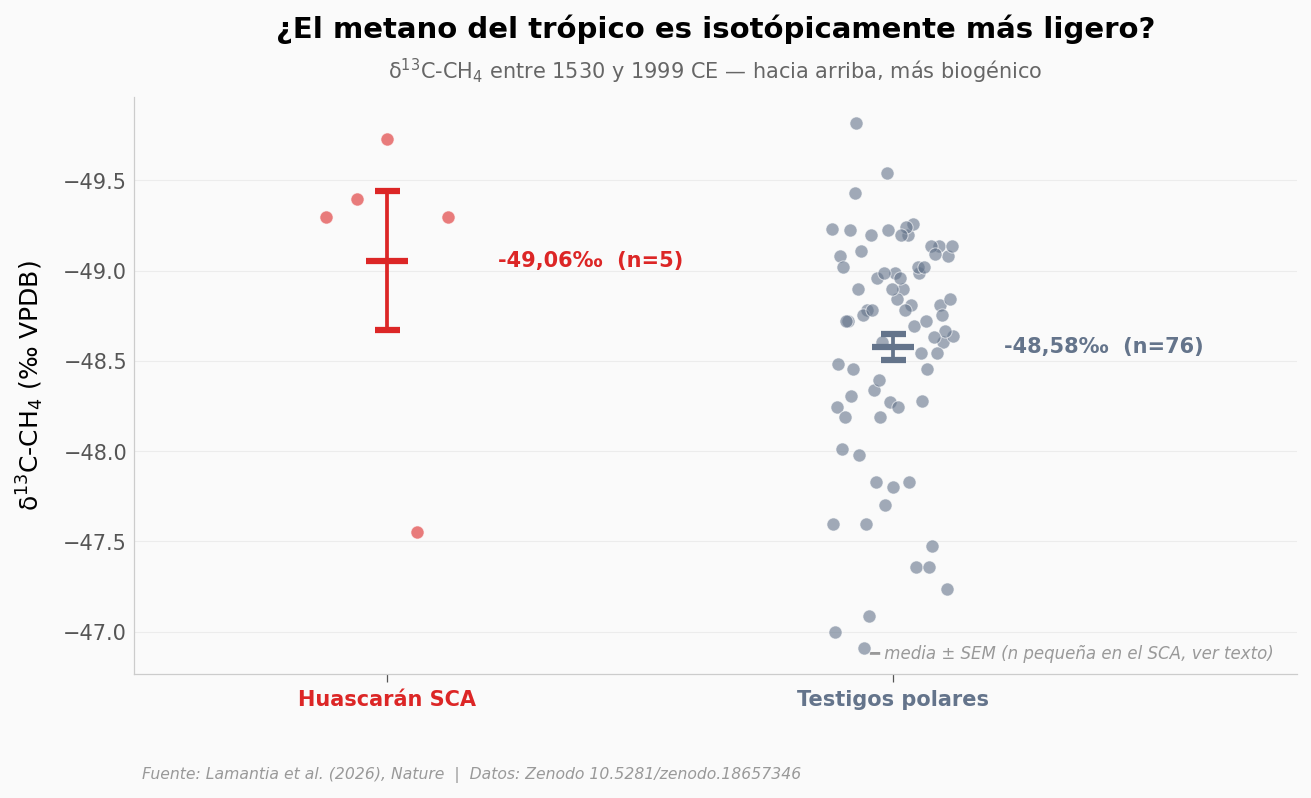

Huascarán  : -49.06 permil  (n=5) -> años [1535, 1650, 1821, 1900, 1999]
Polares    : -48.58 permil  (n=76)
Diferencia : -0.48 permil  (negativo = más biogénico)

Con n=5 no corremos test de hipótesis: la dirección es la esperada,
pero la base muestral no da para cuantificar el efecto.


In [4]:
sca_d13  = d13c[d13c.registro == 'Huascaran_SCA']
pol_d13  = d13c[(d13c.registro != 'Huascaran_SCA') &
                (d13c.year_CE >= 1530) & (d13c.year_CE <= 1999)]

fig, ax = plt.subplots(figsize=(10, 5))
np.random.seed(42)
grupos = [('Huascarán SCA', sca_d13.d13c_permil.values, COLOR_TROPICO),
          ('Testigos polares', pol_d13.d13c_permil.values, '#64748B')]
posiciones = [0, 1]

for i, (nombre, vals, col) in enumerate(grupos):
    n = len(vals)
    x_strip = np.linspace(posiciones[i] - 0.12, posiciones[i] + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=col, s=40, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(posiciones[i], media, yerr=sem, fmt='_', color=col,
                markersize=20, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    ax.text(posiciones[i] + 0.22, media, f'{es(media, 2)}‰  (n={n})',
            fontsize=10, fontweight='bold', color=col, va='center')

ax.set_xticks(posiciones)
ax.set_xticklabels([g[0] for g in grupos], fontsize=10, fontweight='bold')
for tick, (_, _, col) in zip(ax.get_xticklabels(), grupos):
    tick.set_color(col)
ax.set_xlim(-0.5, 1.8)
ax.invert_yaxis()   # más negativo = más biogénico: arriba

ax.set_title('¿El metano del trópico es isotópicamente más ligero?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'δ$^{13}$C-CH$_4$ entre 1530 y 1999 CE — hacia arriba, más biogénico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('δ$^{13}$C-CH$_4$ (‰ VPDB)')
ax.text(0.98, 0.02, '━ media ± SEM (n pequeña en el SCA, ver texto)', transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/d13c_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

delta = sca_d13.d13c_permil.mean() - pol_d13.d13c_permil.mean()
print(f'Huascarán  : {sca_d13.d13c_permil.mean():.2f} permil  (n={len(sca_d13)}) '
      f'-> años {sorted(sca_d13.year_CE.astype(int).tolist())}')
print(f'Polares    : {pol_d13.d13c_permil.mean():.2f} permil  (n={len(pol_d13)})')
print(f'Diferencia : {delta:+.2f} permil  (negativo = más biogénico)')
print('\nCon n=5 no corremos test de hipótesis: la dirección es la esperada,')
print('pero la base muestral no da para cuantificar el efecto.')

## De un desnivel a un presupuesto de emisiones

Aquí es donde el paper deja de medir y empieza a inferir, y conviene decirlo claro.

Los autores meten los registros en un modelo atmosférico de **cuatro cajas** —hemisferio norte, trópico norte, trópico sur, hemisferio sur— y lo invierten: en vez de preguntar "con estas emisiones, ¿qué concentración sale?", preguntan "con estas concentraciones medidas, ¿qué emisiones hacen falta?". Cada caja tiene un tiempo de vida del CH₄ fijo y unas tasas de intercambio fijas entre vecinas. Encima corre un Monte Carlo de 1.000 iteraciones metiendo ruido gaussiano de σ = 5 ppb en las concentraciones.

Lo corremos dos veces: una **solo con testigos polares**, otra **añadiendo el Huascarán** como restricción de la caja del trópico sur. La celda de abajo re-ejecuta el modelo de los autores con su misma semilla (42) — no cargamos un resultado precocinado.

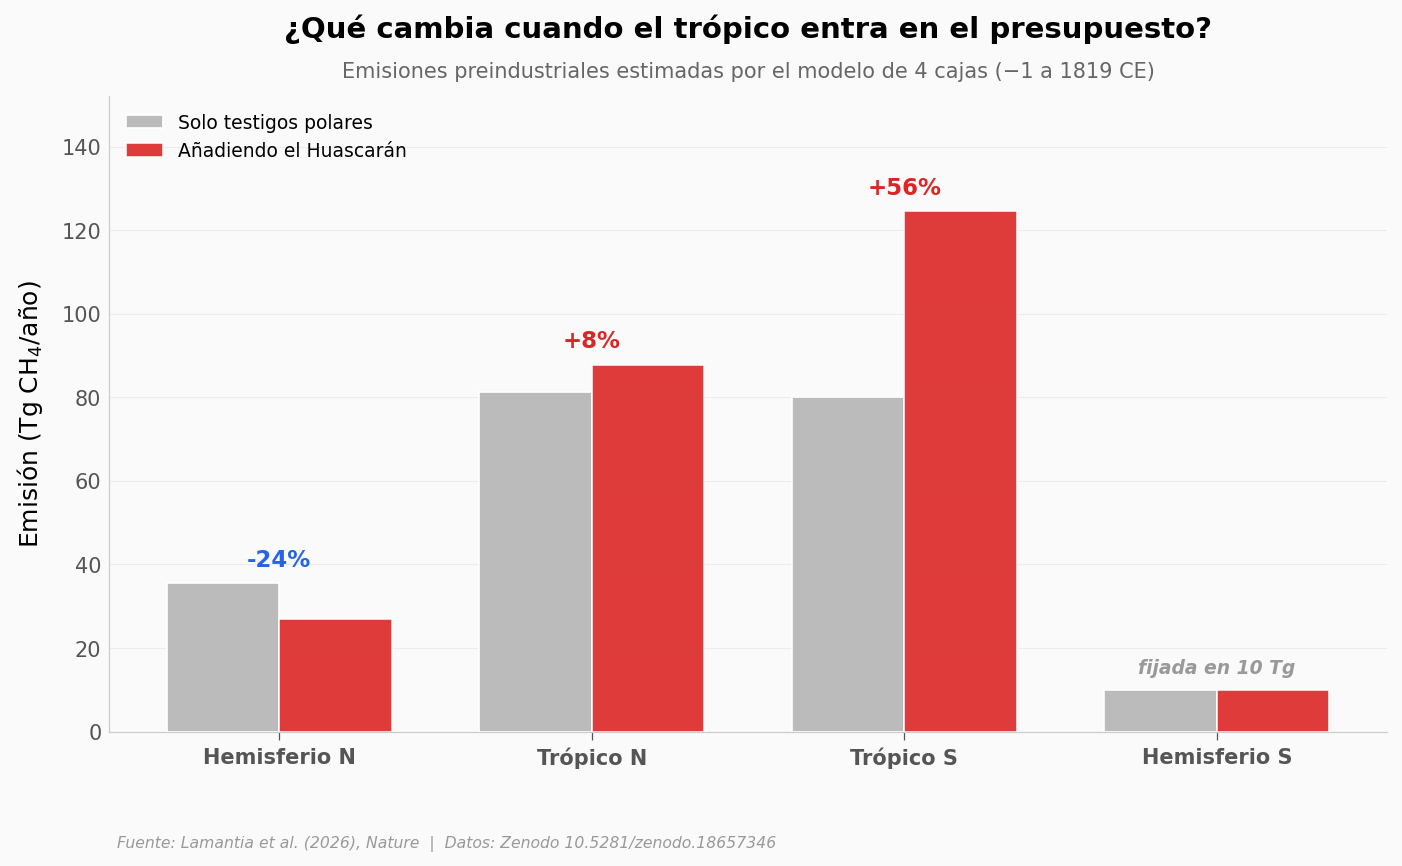

caja             solo polares   + Huascarán    cambio
Hemisferio N          35.5 Tg       26.9 Tg    -24.3%
Trópico N             81.3 Tg       87.8 Tg      8.0%
Trópico S             80.1 Tg      124.7 Tg     55.6%
Hemisferio S          10.0 Tg       10.0 Tg      0.0%
Trópicos (N+S)       161.4 Tg      212.5 Tg     31.6%
TOTAL                206.9 Tg      249.4 Tg     20.5%

Fracción tropical del total: 78.0% -> 85.2%
Pasos con trópicos > extratrópicos: 360/360 (solo polares), 360/360 (+ Huascarán)
Incertidumbre Monte Carlo en los trópicos: 0.56% -> 1.54% (solo propaga el ruido de ±5 ppb)


In [5]:
# ── Modelo de 4 cajas (Lamantia et al. 2026), re-ejecutado aquí ────────────
Mtrop, MCH4 = 178e18, 16          # moles de aire troposférico, g/mol de CH4
VIDA = {'NH': 15.6, 'TN': 6, 'TS': 6, 'SH': 24}      # años, fijos
r_NT, r_TS, r_SH = 0.22, 0.45, 0.45                  # intercambio entre cajas, 1/año
K = (Mtrop / 4) * (MCH4 / 1e12) / 1e9                # ppb -> Tg, cada caja = 1/4 troposfera
N_ITER, RUIDO_PPB, VENTANA = 1000, 5, 20

def _cargar(f):
    d = pd.read_csv(f'datos/{f}')
    d['age_BP'] = 1950 - d['age_AD']
    return d[['age_BP', 'CH4']]

gisp, wais = _cargar('mitchell_gisp2.csv'), _cargar('mitchell_wais.csv')
neem, summit = _cargar('rhodes_neem.csv'), _cargar('huascaran_20yr_avgs.csv')
nh = pd.concat([gisp, neem], ignore_index=True).sort_values('age_BP')

# Rejilla común de 360 pasos (5 años), definida por el rango de edades del WAIS
EDAD = np.linspace(wais.age_BP.min(), wais.age_BP.max(), 360)
_ip = lambda d: interp1d(d.age_BP, d.CH4, kind='linear',
                         fill_value='extrapolate')(EDAD)
CH4_NH, CH4_SH, CH4_SU = _ip(nh), _ip(wais), _ip(summit)
# El testigo tropical se suaviza por su baja resolución temporal (mediana: 25 años entre muestras)
CH4_SU_SUAVE = gaussian_filter1d(CH4_SU, sigma=10)

def _suavizar(a):
    return np.column_stack([uniform_filter1d(a[:, k], size=VENTANA)
                            for k in range(a.shape[1])])

def correr_modelo(con_sca):
    """Invierte el modelo de cajas. Devuelve emisiones suavizadas [NH, TropN, TropS, SH] en Tg/año."""
    rng = np.random.default_rng(42)
    F = np.zeros((360, 4, N_ITER))
    A = np.array([[-(r_NT + r_TS), r_TS], [r_TS, -(r_TS + r_SH)]], float)
    for i in range(N_ITER):
        for j in range(360):
            nh_v = CH4_NH[j] + rng.normal(0, RUIDO_PPB)
            if con_sca:
                ts_v = CH4_SU_SUAVE[j] + rng.normal(0, RUIDO_PPB)
            sh_v = CH4_SH[j] + rng.normal(0, RUIDO_PPB)
            C_NH = (nh_v - 0.07 * (nh_v - sh_v)) * K
            C_SH = sh_v * K
            if con_sca:
                C_TS = ts_v * K
                C_TN = (r_NT * C_NH + r_TS * C_TS) / (r_NT + r_TS)
                E_SH = 10.0                      # fijada, no se resuelve
            else:
                C_TN, C_TS = np.linalg.solve(A, np.array([-r_NT * C_NH, -r_SH * C_SH]))
                E_SH = min(1 / VIDA['SH'] * C_SH + r_SH * (C_SH - C_TS), 10.0)
            E_NH = 1 / VIDA['NH'] * C_NH + r_NT * (C_NH - C_TN)
            E_TN = 1 / VIDA['TN'] * C_TN + r_NT * (C_TN - C_NH) + r_TS * (C_TN - C_TS)
            E_TS = 1 / VIDA['TS'] * C_TS + r_TS * (C_TS - C_TN) + r_SH * (C_TS - C_SH)
            F[j, :, i] = [E_NH, E_TN, E_TS, E_SH]
    medias = F.mean(axis=2)
    incert = (F.std(axis=2) / medias) * 100
    return _suavizar(medias), _suavizar(incert)

emis_polar, inc_polar = correr_modelo(con_sca=False)
emis_sca,   inc_sca   = correr_modelo(con_sca=True)

CAJAS = ['Hemisferio N', 'Trópico N', 'Trópico S', 'Hemisferio S']
m_polar, m_sca = emis_polar.mean(axis=0), emis_sca.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(4)
ancho = 0.36
ax.bar(x - ancho / 2, m_polar, ancho, color=COLOR_CONTEXTO,
       edgecolor='white', linewidth=0.8, label='Solo testigos polares', zorder=3)
ax.bar(x + ancho / 2, m_sca, ancho, color=COLOR_TROPICO, alpha=0.9,
       edgecolor='white', linewidth=0.8, label='Añadiendo el Huascarán', zorder=3)

for i in range(4):
    cambio = 100 * (m_sca[i] / m_polar[i] - 1)
    alto = max(m_polar[i], m_sca[i])
    if abs(cambio) < 0.5:
        # La caja del hemisferio sur no la resuelve el modelo: la fija
        ax.text(x[i], alto + 4, 'fijada en 10 Tg', ha='center', fontsize=9,
                fontweight='bold', color='#999999', style='italic')
    else:
        ax.text(x[i], alto + 4, f'{cambio:+.0f}%', ha='center', fontsize=11,
                fontweight='bold',
                color=COLOR_TROPICO if cambio > 0 else COLOR_DATOS)
ax.set_ylim(0, max(m_polar.max(), m_sca.max()) * 1.22)
ax.set_xticks(x)
ax.set_xticklabels(CAJAS, fontsize=10, fontweight='bold')
ax.set_title('¿Qué cambia cuando el trópico entra en el presupuesto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Emisiones preindustriales estimadas por el modelo de 4 cajas (−1 a 1819 CE)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Emisión (Tg CH$_4$/año)')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/modelo_cajas.png', dpi=200, bbox_inches='tight')
plt.show()

trop_p, trop_s = m_polar[1] + m_polar[2], m_sca[1] + m_sca[2]
tot_p, tot_s = m_polar.sum(), m_sca.sum()
print(f'{"caja":<15}{"solo polares":>14}{"+ Huascarán":>14}{"cambio":>10}')
for i, c in enumerate(CAJAS):
    print(f'{c:<15}{m_polar[i]:>11.1f} Tg{m_sca[i]:>11.1f} Tg'
          f'{100 * (m_sca[i] / m_polar[i] - 1):>9.1f}%')
print(f'{"Trópicos (N+S)":<15}{trop_p:>11.1f} Tg{trop_s:>11.1f} Tg'
      f'{100 * (trop_s / trop_p - 1):>9.1f}%')
print(f'{"TOTAL":<15}{tot_p:>11.1f} Tg{tot_s:>11.1f} Tg'
      f'{100 * (tot_s / tot_p - 1):>9.1f}%')
print(f'\nFracción tropical del total: {100 * trop_p / tot_p:.1f}% -> {100 * trop_s / tot_s:.1f}%')

dom_p = ((emis_polar[:, 1] + emis_polar[:, 2]) >
         (emis_polar[:, 0] + emis_polar[:, 3])).sum()
dom_s = ((emis_sca[:, 1] + emis_sca[:, 2]) >
         (emis_sca[:, 0] + emis_sca[:, 3])).sum()
print(f'Pasos con trópicos > extratrópicos: {dom_p}/360 (solo polares), '
      f'{dom_s}/360 (+ Huascarán)')
print(f'Incertidumbre Monte Carlo en los trópicos: '
      f'{inc_polar[:, 1:3].mean():.2f}% -> {inc_sca[:, 1:3].mean():.2f}% '
      f'(solo propaga el ruido de ±{RUIDO_PPB} ppb)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Un registro de ~2.000 años de CH₄ en un testigo tropical | ✅ | 50 muestras, de −165 a 2012 CE (2.177 años). "2.000 años" es el redondeo del paper; la resolución es irregular: 25 años entre muestras en la mediana, con huecos de hasta 665. |
| Las tendencias coinciden a grandes rasgos con los registros polares | ✅ | Misma escala y misma forma general, pero con desnivel sistemático. Punto a punto contra Law Dome la correlación es **moderada**: r = 0,52 (r² = 0,27, n = 31; Shapiro p > 0,05 en ambas, así que Pearson aplica). No es "coinciden" a secas. |
| El Huascarán está por encima de los polares en el preindustrial | ✅ | +62,3 ppb de media (mediana +62,8; DE 32,4; Cohen's d = 1,92 contra cero, p = 5,8·10⁻⁴³), 119 de 123 comparaciones positivas — 31 muestras tropicales × 4 testigos. Por testigo, con d pareado: WAIS +86,2 (d = 3,84) · Law Dome +84,6 (d = 3,77) · GISP2 +41,2 (d = 1,86) · NEEM +36,5 ppb (d = 1,53). |
| El δ¹³C es consistente con una fuente tropical dominante | ⚠️ | La dirección es la correcta: −49,06‰ en el Huascarán frente a −48,58‰ en los polares (Δ = −0,48‰). Cohen's d = −0,74 y Mann-Whitney p = 0,030 — no t-test: Shapiro rechaza normalidad en ambos grupos (p = 0,021 y p = 0,0004). Pero **n = 5** contra 76 valores polares agrupados de cuatro testigos con ventanas de edad distintas: con esa n el efecto se calcula, pero su intervalo es demasiado ancho para tomarlo como medición. Es una pista compatible. |
| Las emisiones ecuatoriales son más altas que lo estimado solo con hielo polar | ⚠️ | Es lo que el modelo **infiere**, no lo que el hielo mide. Trópicos: 161,4 → 212,5 Tg CH₄/año (+31,6%); trópico sur 80,1 → 124,7 (+55,6%). El abstract no da cifra — estos números salen de re-ejecutar el código de los autores, y el paper lo enmarca como "indican", no como demostración. |
| Dominancia tropical sostenida durante dos milenios | ✅ | Trópicos > extratrópicos en los 360 pasos de tiempo, que cubren de −1 a 1819 CE (1.820 años). Con un matiz importante: **ya ocurre sin el Huascarán** (78% del total). El testigo tropical no crea la dominancia, la sube al 85%. |

> **Limitaciones.**
> - **El modelo no llega al presente.** Cubre de −1 a 1819 CE, porque la rejilla temporal la define el rango de edades del WAIS. Todo lo del modelo es preindustrial; no dice nada del metano actual.
> - **La emisión del hemisferio sur está fijada en 10 Tg/año** en la corrida con Huascarán, y topada en ese mismo valor en la polar. El modelo no la resuelve: la asume.
> - **La barra de error del ensemble engaña por pequeña.** El Monte Carlo (0,6% → 1,5% en los trópicos) solo propaga el ruido de ±5 ppb en las concentraciones. Los tiempos de vida del CH₄ y las tasas de intercambio entre cajas son **parámetros fijos**, sin incertidumbre asociada. La barra real es bastante mayor.
> - **Cada caja se asume igual a un cuarto de la masa troposférica**, una simplificación geométrica.
> - **Error analítico (lo reporta el paper; no se puede recomputar desde estos CSV):** ±3,74 ppb en el Huascarán, ±2,4 ppb en los polares. El desnivel de +62 ppb está muy por encima de ese ruido, pero conviene tenerlo a la vista.
> - Esto es un registro **observacional**. El modelo estima qué emisiones son compatibles con lo medido; no identifica qué las produjo ni dónde exactamente.

## Ahora tú

**1. ¿Cuánto depende el resultado de dónde cortas el preindustrial?**
Mueve `CORTE_PREINDUSTRIAL` a 1700 o a 1800 y vuelve a correr el histograma. ¿El desnivel medio se sostiene?
*Pista:* `sca_pi = sca[sca.year_CE < 1800]` y repite el bloque de interpolación.

**2. ¿El desnivel es igual contra Groenlandia que contra la Antártida?**
Los cuatro testigos no dan lo mismo: WAIS y Law Dome (Antártida) rondan +85 ppb, GISP2 y NEEM (Groenlandia) rondan +39.
*Pista:* `np.mean([por_registro['WAIS'].mean(), por_registro['LawDome'].mean()])` frente al par de Groenlandia.

**3. ¿Qué tan sólido es el número de emisiones si el tiempo de vida del CH₄ tropical no fuera exactamente 6 años?**
Ese 6 es un parámetro fijo del modelo, no un dato medido. La celda de abajo lo pone a prueba.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto de "212 Tg/año" es dato y cuánto es la vida del CH$_4$ que asumimos?
# Corremos el modelo sin ruido (determinista, instantáneo) variando SOLO ese parámetro.

def emisiones_deterministas(vida_tropical, con_sca=True):
    """Emisión tropical media (Tg/año) para un tiempo de vida tropical dado, sin Monte Carlo."""
    C_NH = (CH4_NH - 0.07 * (CH4_NH - CH4_SH)) * K
    C_SH = CH4_SH * K
    if con_sca:
        C_TS = CH4_SU_SUAVE * K
        C_TN = (r_NT * C_NH + r_TS * C_TS) / (r_NT + r_TS)
    else:
        A = np.array([[-(r_NT + r_TS), r_TS], [r_TS, -(r_TS + r_SH)]], float)
        sol = np.linalg.solve(A, np.vstack([-r_NT * C_NH, -r_SH * C_SH]))
        C_TN, C_TS = sol[0], sol[1]
    E_TN = C_TN / vida_tropical + r_NT * (C_TN - C_NH) + r_TS * (C_TN - C_TS)
    E_TS = C_TS / vida_tropical + r_TS * (C_TS - C_TN) + r_SH * (C_TS - C_SH)
    return (E_TN + E_TS).mean()

base = emisiones_deterministas(6)
print(f'{"vida tropical":>15}{"trópicos":>14}{"vs 6 años":>12}')
for vida in [4, 5, 6, 7, 8, 10]:
    e = emisiones_deterministas(vida)
    marca = '  <- valor del paper' if vida == 6 else ''
    print(f'{vida:>12} años{es(e):>10} Tg{es(100 * (e / base - 1)):>10}%{marca}')

print(f'\nEl desnivel medido entre el Huascarán y los polos es de {es(difs.mean())} ppb:')
print('eso es un dato. El salto a "Tg de metano al año" pasa por este parámetro,')
print('que el modelo fija y no mide. Bájalo un 33% (de 6 a 4 años) y la emisión sube un 42%;')
print('súbelo un 33% (de 6 a 8 años) y baja un 21%. La respuesta es fuerte y asimétrica.')

  vida tropical      trópicos   vs 6 años
           4 años     301,3 Tg      41,8%
           5 años     248,0 Tg      16,7%
           6 años     212,5 Tg       0,0%  <- valor del paper
           7 años     187,1 Tg     -11,9%
           8 años     168,1 Tg     -20,9%
          10 años     141,4 Tg     -33,4%

El desnivel medido entre el Huascarán y los polos es de 62,3 ppb:
eso es un dato. El salto a "Tg de metano al año" pasa por este parámetro,
que el modelo fija y no mide. Bájalo un 33% (de 6 a 4 años) y la emisión sube un 42%;
súbelo un 33% (de 6 a 8 años) y baja un 21%. La respuesta es fuerte y asimétrica.


---

## Cómo reproducir esto

Todo lo de arriba sale de seis CSV (menos de 1 MB en total) y del código de modelo que los autores publicaron con el paper. El modelo de cuatro cajas se re-ejecuta en la celda de arriba con la semilla original: no cargamos un resultado precocinado. Los datos y este notebook viven en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-08-19-metano-tropical-huascaran), y el botón de Colab del principio lo abre sin instalar nada.

## Fuentes

**Paper**: [A global atmospheric methane record from a tropical ice core](https://doi.org/10.1038/s41586-026-10938-1)  
*Nature, 2026-08-19*

**Datos**: [A Global Atmospheric Methane Record from a Tropical Ice Core (v2)](https://doi.org/10.5281/zenodo.18657346)  
*Zenodo — CH₄ y δ¹³C de los cinco testigos, y el código del modelo de 4 cajas*

**Referencias citadas**: [Science](https://doi.org/10.1126/science.1238920) · [Earth and Planetary Science Letters](https://doi.org/10.1016/j.epsl.2013.02.034) · [Earth System Science Data](https://doi.org/10.5194/essd-11-473-2019) · [NOAA Global Monitoring Laboratory](https://doi.org/10.15138/P8XG-AA10) · [Quaternary Science Reviews](https://doi.org/10.1016/j.quascirev.2009.05.023) · [Global Biogeochemical Cycles](https://doi.org/10.1029/2009GB003460) · [Science](https://doi.org/10.1126/science.1115193) · [Nature](https://doi.org/10.1038/nature11461)

*20 afirmaciones del notebook verificadas contra estas fuentes*